In [19]:
### Fine-Tuning a Pre-trained LLM
import numpy as np
import evaluate
import torch
from peft import LoraConfig, TaskType, get_peft_model
from datasets import load_dataset
from transformers import AutoTokenizer, BertForSequenceClassification, TrainingArguments, Trainer

In [20]:
model_name = 'bert-base-cased'
peft_config = LoraConfig(task_type=TaskType.SEQ_CLS, inference_mode=False, r=8, lora_alpha=32, lora_dropout=0.1)

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = BertForSequenceClassification.from_pretrained(model_name, num_labels=2, pad_token_id=tokenizer.eos_token_id)
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})
    model.resize_token_embeddings(len(tokenizer))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 296,450 || all params: 108,608,260 || trainable%: 0.2730


In [21]:
ds = load_dataset("imdb")

In [22]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [23]:
def tokenize_function(data):
    return tokenizer(data["text"], padding="max_length", truncation=True)

tokenized_datasets = ds.map(tokenize_function, batched=True)
small_train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(500))
small_eval_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(500))

Map: 100%|██████████| 25000/25000 [00:09<00:00, 2598.73 examples/s]


In [24]:
metric = evaluate.load("accuracy")

In [25]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [26]:
training_args = TrainingArguments(output_dir="test_trainer", num_train_epochs=5)

In [27]:
trainer = Trainer(
  model=model,
  args=training_args,
  train_dataset=small_train_dataset,
  eval_dataset=small_eval_dataset,
  compute_metrics=compute_metrics,
)

In [28]:
trainer.train()

c:\Users\Bade\anaconda3\envs\aiml\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss


TrainOutput(global_step=315, training_loss=0.6710431780133929, metrics={'train_runtime': 4118.6245, 'train_samples_per_second': 0.607, 'train_steps_per_second': 0.076, 'total_flos': 660054374400000.0, 'train_loss': 0.6710431780133929, 'epoch': 5.0})

In [33]:
trainer.evaluate()

c:\Users\Bade\anaconda3\envs\aiml\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.6177336573600769,
 'eval_accuracy': 0.688,
 'eval_runtime': 186.6918,
 'eval_samples_per_second': 2.678,
 'eval_steps_per_second': 0.337,
 'epoch': 5.0}

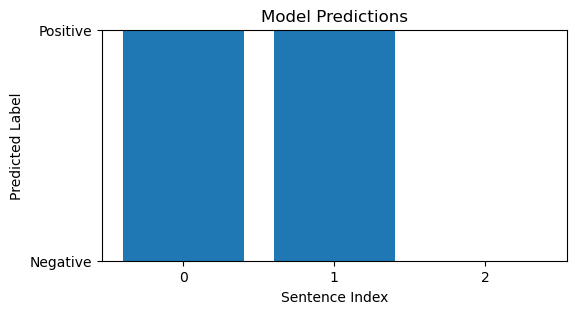

In [51]:
import matplotlib.pyplot as plt

# Example predictions from multiple sentences
sentences = [
    "My family enjoyed this movie. It's a blast for adults and kids!",
    "A rip-roaring fusion of masterful visual storytelling and toe-tapping music, writer-director Ryan Coogler's first original blockbuster reveals the full scope of his singular imagination.",
    "This movie was terrible and a waste of time."
]

predictions = []
for sentence in sentences:
    tokenized = tokenizer(sentence, padding="max_length", truncation=True, return_tensors="pt")
    model.eval()
    
    with torch.no_grad():
        outputs = model(**tokenized)
        pred = torch.argmax(outputs.logits, dim=-1)
        predictions.append(pred.item())

# Create bar chart
plt.figure(figsize=(6, 3))
plt.bar(range(len(predictions)), predictions)
plt.xlabel("Sentence Index")
plt.ylabel("Predicted Label")
plt.title("Model Predictions")
plt.xticks(range(len(predictions)))
plt.yticks([0, 1], ["Negative", "Positive"])
plt.ylim(0, 1)
plt.show()

In [52]:
sentence = "This movie was terrible and a waste of time."
tokenized = tokenizer(sentence, padding="max_length", truncation=True, return_tensors="pt")
model.eval()

with torch.no_grad():
    outputs = model(**tokenized)
    predictions = torch.argmax(outputs.logits, dim=-1)
    print(f"Prediction: {predictions.item()}")

Prediction: 0


In [53]:
sentence = "A rip-roaring fusion of masterful visual storytelling and toe-tapping music, writer-director Ryan Coogler's first original blockbuster reveals the full scope of his singular imagination."
tokenized = tokenizer(sentence, padding="max_length", truncation=True, return_tensors="pt")
model.eval()

with torch.no_grad():
    outputs = model(**tokenized)
    predictions = torch.argmax(outputs.logits, dim=-1)
    print(f"Prediction: {predictions.item()}")

Prediction: 1
